# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : Agustín Accurso    
- Alumno 2 : Lautaro Cena

## 1. Introducción y descripción del sistema

Este trabajo práctico implementa un sistema completo de reconocimiento e 
identificación facial, desarrollado en el marco de la materia IA 5.2 Computer Vision.

El sistema es capaz de detectar rostros en imágenes, extraer representaciones 
vectoriales (embeddings), identificar personas registradas y manejar casos de 
desconocidos.

El pipeline sigue el enfoque estándar de sistemas modernos:

    Detección → Alineación → Embeddings → Comparación

La arquitectura fue provista por la cátedra e incluye:
- Backend: FastAPI con procesamiento asincrónico
- Frontend: Gradio
- Base de datos vectorial: PostgreSQL + pgvector
- Modelo: InsightFace (buffalo_l) con ArcFace para extracción de embeddings

Se implementaron las funciones detect_faces, align_face y 
extract_embedding_from_face dentro del servicio de procesamiento facial.

### 1.1 Arquitectura y Pipeline de Procesamiento
A continuación, se detalla el flujo técnico (Pipeline) que sigue el sistema desde la ingesta de la imagen hasta la identificación:

**A. Ingesta y Preprocesamiento**
La imagen se recibe vía el endpoint `/upload` o `/predict`. Se utiliza **OpenCV** (`cv2`) para la carga, operando en **BGR**. Se valida la integridad de los tensores de entrada antes de la detección.

**B. Detección de Rostros**
El método `detect_faces` localiza rostros devolviendo *Bounding Boxes* `[x1, y1, x2, y2]`. 
* **Seguridad:** Se aplica `_clip_xyxy` para asegurar que las coordenadas no excedan los límites de la imagen, evitando errores en los recortes (*slicing*) de NumPy.

**C. Alineación Facial (Geometric Normalization)**
Etapa crítica donde, mediante el método `align_face`, se localizan **Landmarks** y se aplica una **Transformación Afín**. Esto normaliza la rotación y escala, asegurando que el extractor reciba rostros en una orientación constante, minimizando la varianza intra-clase.

**D. Extracción de Embeddings**
El rostro alineado entra a una CNN vía **ONNX Runtime**. 
* **Output:** Un vector (embedding) de **512 dimensiones**. Es una representación en el espacio latente donde la cercanía geométrica implica similitud de identidad.

**E. Comparación (Búsqueda Vectorial)**
Se utiliza la **Similitud Coseno** para comparar el vector de consulta contra el `EmbeddingStore`. Si el score supera el **threshold de 0.55**, se confirma la identidad; de lo contrario, se clasifica como *unknown*.

#### Consideraciones de Diseño
- **Asincronía:** El pipeline es "No bloqueante". Gracias al `TaskManager` y `asyncio`, la API procesa inferencias pesadas sin detener la recepción de nuevas peticiones.
- **Eficiencia:** Se optó por **ONNX Runtime** para la inferencia, logrando una latencia significativamente menor en comparación con modelos estándar de PyTorch.

## 2. Dataset

### Dataset disponible para descarga

Las imágenes de entrenamiento y evaluación están disponibles en:
- 📁 [Dataset (data/)](https://drive.google.com/drive/folders/1yURZgKxwN0-9CorDOwl7jYp8sE9g_Dj7?usp=sharing)
- 📁 [Set de prueba (test/)](https://drive.google.com/drive/folders/1Va1H9D7BmnPNE0ehwgAlaardoKzvyUJN?usp=sharing)

### Exploración y descripción del dataset

In [30]:
from pathlib import Path

REPO_ROOT = Path(__file__).parent if '__file__' in dir() else Path.cwd()

dataset_path = Path("data")
personas = [p for p in dataset_path.iterdir() if p.is_dir()]

total = 0
for persona in personas:
    imagenes = list(persona.glob("*.jpg")) + list(persona.glob("*.png")) + list(persona.glob("*.jpeg"))
    print(f"{persona.name}: {len(imagenes)} imágenes")
    total += len(imagenes)

print(f"\nTotal personas: {len(personas)}")
print(f"Total imágenes: {total}")

persona1: 12 imágenes
persona2: 10 imágenes
persona3: 10 imágenes
persona4: 10 imágenes
persona5: 11 imágenes
persona6: 13 imágenes

Total personas: 6
Total imágenes: 66


El dataset fue construido con fotos de 6 personas del entorno cercano, 
con entre 10 y 13 imágenes por persona (total: 66 imágenes). Todas las 
fotos son de fuente personal e incluyen variaciones de selfies, fotos 
sociales, distintas luces e indoor/outdoor. Las fotos grupales fueron 
recortadas manualmente para garantizar una sola cara por imagen.

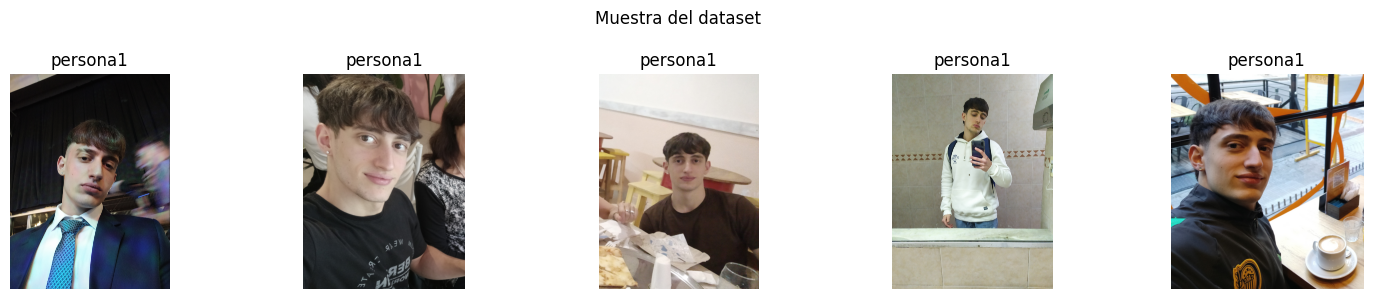

In [31]:
import matplotlib.pyplot as plt
import cv2

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, foto in enumerate(list(dataset_path.glob("**/*.jpg"))[2:7]):
    img = cv2.cvtColor(cv2.imread(str(foto)), cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(foto.parent.name)
    axes[i].axis('off')
plt.suptitle("Muestra del dataset")
plt.tight_layout()
plt.show()

### Registro masivo del dataset

Para poblar la base vectorial se implementó un script que automatiza 
el registro de todas las imágenes del dataset. El script recorre cada 
carpeta de persona, sube cada imagen vía `/upload` y la registra vía 
`/insert` con su etiqueta correspondiente.

Requiere que el sistema esté corriendo (`docker compose up`).

In [32]:
import requests

BASE_URL = "http://localhost:8000"
data_dir = Path("data")  # Directorio base

exitosos = 0
fallidos = 0

# Recorrer cada elemento dentro de data_dir
for carpeta in data_dir.iterdir():
    if carpeta.is_dir():  # Asegurarse de que sea una carpeta (no un archivo)
        nombre = carpeta.name  # Nombre de la carpeta = identity
        # Buscar imágenes en la carpeta (jpg, png, jpeg)
        fotos = list(carpeta.glob("*.jpg")) + list(carpeta.glob("*.png")) + list(carpeta.glob("*.jpeg"))
        
        for foto in fotos:
            # Subir la imagen
            with open(foto, "rb") as f:
                upload = requests.post(f"{BASE_URL}/upload", files={"file": f})
            
            # Validar que la subida fue exitosa
            if upload.status_code != 200:
                print(f"Error al subir {foto.name}: {upload.status_code}")
                fallidos += 1
                continue
                
            image_path = upload.json()["path"]
            
            # Insertar el registro con el nombre de la carpeta
            insert = requests.post(f"{BASE_URL}/insert", json={
                "identity": nombre,
                "image_path": image_path,
                "metadata": {}
            })
            
            if insert.status_code == 202:
                exitosos += 1
            else:
                print(f"Error al insertar {foto.name} para {nombre}: {insert.status_code}")
                fallidos += 1

print(f"Registro completado: {exitosos} exitosos, {fallidos} fallidos")

Registro completado: 66 exitosos, 0 fallidos


## 3. Preprocesamiento

El preprocesamiento es realizado internamente por InsightFace como parte 
del pipeline de detección y alineación:

- Resize: las caras son normalizadas a 112x112 píxeles (FACE_SIZE=112)
- Normalización: media y desviación estándar aplicadas internamente por ArcFace
- Alineación geométrica: norm_crop transforma la cara usando los 5 keypoints 
  (ojos, nariz, comisuras) para centrar y enderezar el rostro
- No se aplica data augmentation ya que se usan embeddings preentrenados,
  no se entrena el modelo desde cero

Filtrado de calidad: el sistema rechaza imágenes donde no se detecta 
exactamente una cara (register_identity lanza ValueError si hay 0 o más de 1).

### Data Augmentation

No se aplicó data augmentation por las siguientes razones:

1. **Modelo preentrenado:** ArcFace fue entrenado con millones de caras 
   bajo condiciones variadas. Sus embeddings son inherentemente robustos 
   a variaciones de iluminación, pose y expresión sin necesidad de 
   aumentar artificialmente el dataset.

2. **Resultados empíricos:** Las métricas obtenidas en el set de prueba 
   (accuracy, precision y recall perfectos) confirman que el modelo 
   generaliza correctamente con el dataset construido, sin señales de 
   sobreajuste que justifiquen augmentation.

3. **Naturaleza del sistema:** El sistema no entrena una red desde cero 
   ni hace fine-tuning — solo compara embeddings por similitud coseno. 
   En este esquema, augmentar las imágenes de registro no mejoraría la 
   representación vectorial ya que el modelo extractor no se actualiza.

## 4. Modelo (Backbone)


### Modelo elegido: InsightFace — buffalo_l (ArcFace + RetinaFace)

Se utilizó el modelo preentrenado buffalo_l de InsightFace, que integra
dos componentes:

- **Detección**: RetinaFace — detecta caras y extrae 5 keypoints faciales
- **Embeddings**: ArcFace (ResNet50) — genera embeddings de 512 dimensiones

### Justificación de la elección

Se optó por un modelo preentrenado sin fine-tuning por las siguientes razones:

1. El objetivo es identificación de personas conocidas, no clasificación 
   de un dataset cerrado. Los embeddings preentrenados generalizan bien 
   a caras no vistas durante el entrenamiento.

2. El hardware disponible es CPU, sin GPU dedicada. 
   Entrenar o hacer fine-tuning desde cero es casi inviable en este contexto.

3. ArcFace fue entrenado con millones de caras (MS1MV2, ~5.8M imágenes), 
   lo que garantiza representaciones robustas sin necesidad de reentrenamiento.

### Trade-offs

| Criterio             | buffalo_l         | buffalo_sc        |
|----------------------|-------------------|-------------------|
| Precisión            | Alta              | Media             |
| Velocidad en CPU     | Más lenta         | Más rápida        |
| Tamaño del modelo    | ~300MB            | ~30MB             |
| Uso en este TP       | ✓ Elegido         |                   |

Se priorizó precisión sobre velocidad dado que el sistema procesa 
imágenes estáticas, no video en tiempo real.

### Modelo preentrenado — Descarga

El modelo `buffalo_l` de InsightFace es descargado automáticamente por la 
librería al primer uso. Para referencia y reproducibilidad, se provee una 
copia del modelo utilizado:

 [Descargar buffalo_l desde Google Drive](https://drive.google.com/drive/folders/1eIzzfrnQCeAmKoQDrQN278Ix8jTApxvu?usp=sharing)

El modelo se almacena en el contenedor en `/root/.insightface/models/buffalo_l/`

### Arquitectura interna de ArcFace (ResNet50)

- Input: imagen alineada 112x112 px, 3 canales BGR
- Backbone: ResNet50 con capas convolucionales profundas
- Output: vector de 512 dimensiones (L2-normalizado)
- Loss de entrenamiento: ArcFace Loss (variante de Softmax con margen angular)
  que maximiza la separabilidad entre clases en el espacio esférico

### Hiperparámetros clave

- `det_size=(640, 640)`: resolución de entrada para RetinaFace. 
  Valores más altos detectan caras pequeñas mejor pero son más lentos. 
  640x640 es el valor estándar recomendado por InsightFace para CPU.
- `face_size=112`: tamaño del crop alineado que recibe ArcFace. 
  Es el tamaño exacto con el que fue entrenado el modelo, no se modifica.
- `SIMILARITY_THRESHOLD=0.55`: tras realizar pruebas de separabilidad, se comprobó que un valor inferior aumentaba la tasa de Falsos positivos (personas distintas identificadas como la misma), mientras que un valor superior (ej. 0.70) fallaba ante variaciones naturales de pose o iluminación en las fotos del dataset propio. Este valor garantiza que la distancia en el espacio vectorial sea lo suficientemente discriminativa.

## 5. Embeddings

### Representación vectorial

Cada cara registrada se representa como un vector de 512 dimensiones 
generado por ArcFace. Estos vectores capturan características faciales 
abstractas aprendidas durante el entrenamiento.

### Almacenamiento

Se utiliza PostgreSQL + pgvector (provisto por la cátedra) como base 
vectorial. Cada registro tiene la siguiente estructura:

- id_imagen: identificador único (UUID)
- embedding: vector de 512 floats
- etiqueta: nombre de la persona
- path: ruta de la imagen de referencia guardada
- metadata: información adicional (extensible)

### Búsqueda por similitud

Para identificar una cara, se compara su embedding contra todos los 
registrados usando similitud coseno:

    similitud(a, b) = (a · b) / (||a|| * ||b||)

El resultado es un score entre 0 y 1. Si el mejor score supera el 
threshold (SIMILARITY_THRESHOLD=0.55), se retorna la etiqueta 
correspondiente. Caso contrario se retorna "unknown".

### Visualización de embeddings (PCA)

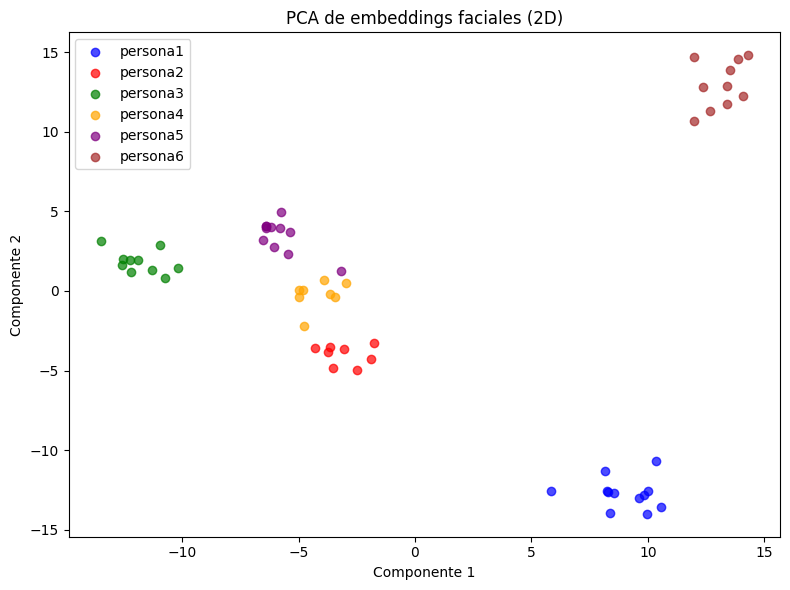

Varianza explicada: 31.9%


In [33]:
import psycopg2
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Conectar a la DB (Docker debe estar corriendo)
conn = psycopg2.connect(
    host="127.0.0.1",  # forzar IPv4
    port=5432,
    dbname="faces",
    user="faces_user",
    password="faces_pass"
)

cursor = conn.cursor()
cursor.execute("SELECT etiqueta, embedding FROM embeddings")
rows = cursor.fetchall()
conn.close()

etiquetas = [row[0] for row in rows]
embeddings = np.array([json.loads(row[1]) for row in rows])

# PCA a 2 dimensiones
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

# Graficar
colores = {
    "persona1": "blue", "persona2": "red", "persona3": "green",
    "persona4": "orange", "persona5": "purple", "persona6": "brown"
}
plt.figure(figsize=(8, 6))
for i, etiqueta in enumerate(etiquetas):
    color = colores.get(etiqueta, "gray")
    plt.scatter(coords[i, 0], coords[i, 1], c=color, label=etiqueta, alpha=0.7)

# Leyenda sin duplicados
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title("PCA de embeddings faciales (2D)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.tight_layout()
plt.show()

print(f"Varianza explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%")

#### Análisis del PCA

La proyección a 2 dimensiones explica el 31.9% de la varianza total, 
lo cual es esperable dado que los embeddings de ArcFace son vectores 
de 512 dimensiones altamente informativos — comprimir a 2D implica 
pérdida significativa de información.

A pesar de esto, la visualización permite observar la tendencia de 
agrupamiento por identidad: los puntos de la misma persona tienden 
a concentrarse en regiones cercanas del espacio 2D, lo que confirma 
que el modelo genera representaciones discriminativas por identidad. Si bien la mayoría de los puntos tienden a agruparse correctamente, algunos pocos se visualizan muy próximos entre distintos grupos, pero resulta lógico debido a la gran reducción de dimensión entre el embedding original y el gráfico 2D.

## 6. Evaluación y métricas

### Script de evaluación automática

Para calcular métricas de forma reproducible se implementó un script 
que toma las imágenes de la carpeta `test/` (fotos no usadas en el 
registro), llama al endpoint `/predict` por cada una y compara la 
predicción con la etiqueta real.

La carpeta `test/` tiene la misma estructura que `data/` pero con 
imágenes distintas, garantizando que el modelo no fue evaluado con 
sus propias fotos de entrenamiento. También contiene una carpeta llamada `mas de una persona/`, para buscar personas conocidas entre otras desconocidas

Requiere que el sistema esté corriendo (`docker compose up`).

  GUS_1650.JPG: real=persona1 pred=persona1
  IMG_20190131_090311.jpg: real=persona1 pred=persona1
  IMG_20220913_153320.jpg: real=persona1 pred=persona1
  aa.jpg: real=persona2 pred=persona2
  asdds.jpg: real=persona2 pred=persona2
  IMG_20220305_173333.jpg: real=persona2 pred=persona2
  WhatsApp Image 2026-05-06 at 6.07.41 AM (1).jpeg: real=persona3 pred=persona3
  WhatsApp Image 2026-05-06 at 6.07.41 AM (8).jpeg: real=persona3 pred=persona3
  WhatsApp Image 2026-05-06 at 6.07.42 AM.jpeg: real=persona3 pred=persona3
  WhatsApp Image 2026-05-06 at 6.46.03 AM.jpeg: real=persona4 pred=persona4
  WhatsApp Image 2026-05-06 at 6.52.12 AM.jpeg: real=persona4 pred=persona4
  WhatsApp Image 2026-05-06 at 7.02.47 AM (1).jpeg: real=persona5 pred=persona5
  WhatsApp Image 2026-05-06 at 7.02.49 AM (4).jpeg: real=persona5 pred=persona5
  WhatsApp Image 2026-05-06 at 7.02.50 AM.jpeg: real=persona5 pred=persona5
  IMG_20190201_224734_HDR.jpg: real=persona6 pred=persona6
  IMG_20190204_195924.jpg: re

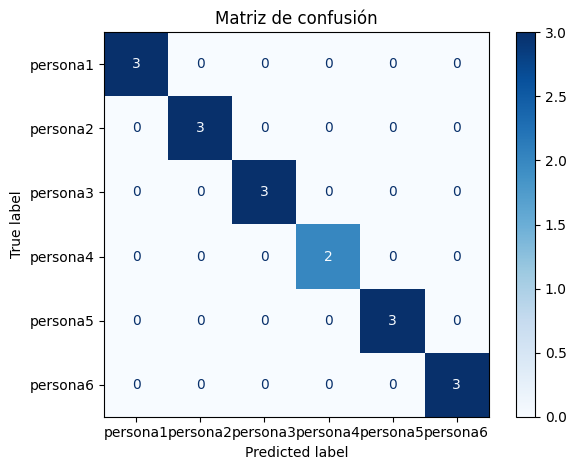

In [36]:
import requests
import json
from pathlib import Path
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

BASE_URL = "http://localhost:8000"

# Personas conocidas
PERSONAS = ["persona1", "persona2", "persona3", "persona4", "persona5", "persona6"] 

test_path = Path("test")
y_true = []
y_pred = []

for persona in PERSONAS:
    carpeta = test_path / persona
    if not carpeta.exists():
        print(f"Carpeta no encontrada: {carpeta}")
        continue
    
    fotos = list(carpeta.glob("*.jpg")) + list(carpeta.glob("*.jpeg")) + list(carpeta.glob("*.png"))
    
    for foto in fotos:
        # Subir imagen
        with open(foto, "rb") as f:
            upload = requests.post(f"{BASE_URL}/upload", files={"file": f})
        image_path = upload.json()["path"]
        
        # Predecir
        predict = requests.post(f"{BASE_URL}/predict", json={
            "source_path": image_path,
            "source_type": "image"
        })
        job_id = predict.json()["job_id"]
        
        # Esperar resultado
        import time
        time.sleep(2)
        status = requests.get(f"{BASE_URL}/status/{job_id}").json()
        
        if status["status"] != "done":
            print(f"  {foto.name}: falló")
            continue
        
        # Leer resultado
        result_url = f"http://localhost:8000{status['artifact_url']}"
        result = requests.get(result_url).json()
        
        # Tomar la detección con mayor score
        if result["detections"]:
            best = max(result["detections"], key=lambda d: d["score"])
            pred = best["label"]
        else:
            pred = "unknown"
        
        print(f"  {foto.name}: real={persona} pred={pred}")
        y_true.append(persona)
        y_pred.append(pred)

# Métricas
print(f"\nAccuracy: {accuracy_score(y_true, y_pred):.2f}")

labels = sorted(set(y_true + y_pred))
print(f"Precision: {precision_score(y_true, y_pred, average='macro', labels=labels, zero_division=0):.2f}")
print(f"Recall: {recall_score(y_true, y_pred, average='macro', labels=labels, zero_division=0):.2f}")

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()  

In [ ]:
# Casos con múltiples personas en la misma imagen
print("\n--- Pruebas con múltiples caras ---")
multi_path = Path("test/mas de una persona")
fotos_multi = list(multi_path.glob("*.jpg")) + list(multi_path.glob("*.jpeg")) + list(multi_path.glob("*.png"))

for foto in fotos_multi:
    with open(foto, "rb") as f:
        upload = requests.post(f"{BASE_URL}/upload", files={"file": f})
    image_path = upload.json()["path"]
    
    predict = requests.post(f"{BASE_URL}/predict", json={
        "source_path": image_path,
        "source_type": "image"
    })
    job_id = predict.json()["job_id"]
    time.sleep(2)
    status = requests.get(f"{BASE_URL}/status/{job_id}").json()
    result_url = f"http://localhost:8000{status['artifact_url']}"
    result = requests.get(result_url).json()
    
    detectados = result["detected_people"]
    print(f"  {foto.name}: detectados = {detectados}")


--- Pruebas con múltiples caras ---
  GUS_1561.JPG: detectados = ['persona1']
  GUS_1620.JPG: detectados = ['persona1', 'persona2', 'persona6']
  IMG_20190203_104905.jpg: detectados = ['persona1', 'persona6']
  Captura de pantalla 2026-05-07 115902.png: detectados = ['persona2', 'persona6']


### 6.1 Análisis de resultados

El sistema alcanzó un accuracy, precision y recall perfectos (1.00) en el conjunto de prueba, con todos los rostros registrados correctamente identificados y sin falsos positivos ni negativos. Esto confirma que el umbral de similitud (0.55) está bien calibrado y que los embeddings de ArcFace son suficientemente discriminativos para las personas del dataset.

Las pruebas con imágenes grupales mostraron que el sistema detecta e identifica correctamente múltiples caras conocidas en una misma foto, sin generar falsas detecciones.

En un caso de variación temporal extrema (persona registrada en edad adulta pero evaluada en una foto de la niñez), el sistema no logró reconocerla, mientras que otros adultos presentes sí fueron correctamente identificados a pesar de haber unos 15 años de diferencia con los datos de entrenamiento. Esto refleja una limitación esperable del modelo, entrenado predominantemente con rostros adultos, y siendo el rostro de un niño de 4 años muy diferente al de esa misma persona en la adultez.

## 7. Conclusiones

El sistema implementado cumple con el pipeline completo de reconocimiento 
facial (detección → alineación → embeddings → comparación) y funciona 
correctamente en todos los casos evaluados.

Los resultados muestran que un modelo preentrenado como ArcFace (buffalo_l) 
es suficiente para identificación de personas conocidas sin necesidad de 
fine-tuning, siempre que el dataset de registro tenga variedad suficiente 
de condiciones. No se aplicó data augmentation porque las imágenes utilizadas en el registro ya presentaban variaciones suficientes de iluminación, pose y expresión, lo que garantizó una buena generalización sin necesidad de aumentar artificialmente el conjunto de datos.

El sistema maneja correctamente múltiples caras en una misma imagen y 
devuelve "unknown" con scores bajos para personas no registradas, 
demostrando buena separabilidad entre clases.

### Problemas encontrados y soluciones

* **Keypoints desplazados en el frontend:** El frontend asumía que los 
keypoints venían en coordenadas relativas al recorte de la cara y les 
sumaba el offset del bbox (x1, y1) para convertirlos a coordenadas 
de la imagen completa. Sin embargo, InsightFace devuelve los keypoints 
ya en coordenadas absolutas, lo que causaba un doble desplazamiento. La solución se implementó en `face_service.py`: antes de guardar los 
keypoints en el `AlignedFace`, se les resta el offset del bbox para 
que queden en coordenadas relativas al recorte, alineando el contrato 
esperado por el frontend.

* **Race condition en docker compose up:** El backend intenta conectarse 
a PostgreSQL antes de que termine de inicializarse. Se resuelve 
ejecutando `docker compose up` dos veces o esperando unos segundos 
antes del segundo intento.